# ACTIVIDAD 9: TRANSFER LEARNING - Clasificación de Melanoma (Cáncer de Piel)

---

En esta actividad, vamos a utilizar **Transfer Learning** con Convolutional Neural Networks para resolver un problema de clasificación de imágenes de melanoma (cáncer de piel). El Transfer Learning nos permite aprovechar modelos pre-entrenados en grandes datasets (como ImageNet) para mejorar el rendimiento en nuestro problema específico.

**Dataset:** Melanoma Skin Cancer Dataset of 10,000 Images

[Dataset en Kaggle](https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images)

**Objetivo:** Crear un clasificador de melanoma utilizando Transfer Learning que supere el rendimiento de una CNN entrenada desde cero.

**Ventajas del Transfer Learning:**
- Menor tiempo de entrenamiento
- Mejor generalización con datasets pequeños
- Aprovecha características aprendidas en millones de imágenes
- Mayor accuracy con menos datos

## Configuración Inicial - GPU

In [40]:
# Configurar TensorFlow para usar GPU
import os
import tensorflow as tf

print("="*80)
print("CONFIGURACIÓN DE GPU CON TENSORFLOW")
print("="*80 + "\n")

# Verificar versión de TensorFlow
print(f"TensorFlow version: {tf.__version__}")

# Configurar para usar GPU si está disponible
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPUs detectadas: {len(gpus)}")

if gpus:
    try:
        # Permitir crecimiento de memoria para evitar que TensorFlow reserve toda la VRAM
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        print(f"✅ GPU configurada correctamente")
        print(f"   Dispositivo: {gpus[0].name}")
        
        # Información adicional de la GPU
        gpu_details = tf.config.experimental.get_device_details(gpus[0])
        if 'device_name' in gpu_details:
            print(f"   Nombre: {gpu_details['device_name']}")
        
    except RuntimeError as e:
        print(f"⚠️ Error configurando GPU: {e}")
else:
    print("⚠️ No se detectaron GPUs. Se usará CPU (entrenamiento más lento)")
    print("   Asegúrate de tener CUDA y cuDNN instalados correctamente.")

# Verificar dispositivo por defecto
print(f"\nDispositivo por defecto: {tf.test.gpu_device_name() if tf.test.is_gpu_available() else 'CPU'}")

print("\n" + "="*80)

CONFIGURACIÓN DE GPU CON TENSORFLOW

TensorFlow version: 2.10.0

GPUs detectadas: 1
✅ GPU configurada correctamente
   Dispositivo: /physical_device:GPU:0
   Nombre: NVIDIA GeForce RTX 4060 Ti

Dispositivo por defecto: /device:GPU:0



## Importación de Librerías

In [41]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Configurar semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Librerías importadas correctamente")
print(f"   Keras version: {keras.__version__}")
print(f"   Numpy version: {np.__version__}")

✅ Librerías importadas correctamente
   Keras version: 2.10.0
   Numpy version: 1.26.4


## Descarga del Dataset

In [42]:
# Descargar el dataset desde Kaggle usando kagglehub
!pip install -q kagglehub

import kagglehub

print("="*80)
print("DESCARGA DEL DATASET DE MELANOMA")
print("="*80 + "\n")

print("Descargando dataset de Melanoma (10,000 imágenes) desde Kaggle...")
print("Esto puede tardar varios minutos dependiendo de tu conexión...\n")

try:
    # Descargar la última versión del dataset
    path = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")

    print(f"\n✅ Dataset descargado correctamente en: {path}")
    print(f"\nContenido del directorio:")

    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Contar archivos de imagen
            image_files = [f for f in os.listdir(item_path) 
                          if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
            print(f"  📁 {item}/ ({len(image_files)} imágenes)")
        else:
            print(f"  📄 {item}")

except Exception as e:
    print(f"\n❌ Error al descargar el dataset: {e}")
    raise

print("\n" + "="*80)

DESCARGA DEL DATASET DE MELANOMA

Descargando dataset de Melanoma (10,000 imágenes) desde Kaggle...
Esto puede tardar varios minutos dependiendo de tu conexión...


✅ Dataset descargado correctamente en: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1

Contenido del directorio:
  📁 melanoma_cancer_dataset/ (0 imágenes)



## Configuración y Carga de Datos

In [43]:
# Configuración
IMG_SIZE = 224  # Tamaño estándar para modelos pre-entrenados (VGG, ResNet, etc.)
BATCH_SIZE = 32
EPOCHS = 50

# Explorar la estructura del dataset
print("="*80)
print("EXPLORACIÓN DEL DATASET")
print("="*80 + "\n")

if 'path' in locals():
    print(f"Ruta del dataset: {path}\n")
    
    # Buscar carpeta principal del dataset
    dataset_root = None
    for item in os.listdir(path):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # Verificar si contiene train y test
            subdirs = os.listdir(item_path) if os.path.exists(item_path) else []
            if 'train' in subdirs and 'test' in subdirs:
                dataset_root = item_path
                break
    
    # Si no se encuentra, usar la ruta directamente
    if dataset_root is None:
        subdirs = os.listdir(path)
        if 'train' in subdirs and 'test' in subdirs:
            dataset_root = path
    
    if dataset_root:
        DATASET_PATH = dataset_root
        TRAIN_PATH = os.path.join(dataset_root, 'train')
        TEST_PATH = os.path.join(dataset_root, 'test')
        
        print(f"📁 Estructura del dataset:")
        print(f"   Root: {dataset_root}")
        print(f"   Train: {TRAIN_PATH}")
        print(f"   Test: {TEST_PATH}\n")
        
        # Explorar clases en train
        class_folders = []
        if os.path.exists(TRAIN_PATH):
            for item in os.listdir(TRAIN_PATH):
                item_path = os.path.join(TRAIN_PATH, item)
                if os.path.isdir(item_path):
                    image_files = [f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
                    if image_files:
                        class_folders.append(item)
                        print(f"📁 Clase en Train: {item} ({len(image_files)} imágenes)")
        
        # Explorar clases en test
        if os.path.exists(TEST_PATH):
            print()
            for item in os.listdir(TEST_PATH):
                item_path = os.path.join(TEST_PATH, item)
                if os.path.isdir(item_path):
                    image_files = [f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
                    if image_files:
                        print(f"📁 Clase en Test: {item} ({len(image_files)} imágenes)")
        
        if class_folders:
            # Mapeo de clases
            MAP_CLASSES = {i: folder for i, folder in enumerate(sorted(class_folders))}
            CLASS_NAMES = {i: folder.replace('_', ' ').title() for i, folder in enumerate(sorted(class_folders))}
            
            print(f"\n✅ Encontradas {len(MAP_CLASSES)} clases:")
            for idx, name in CLASS_NAMES.items():
                print(f"   {idx}: {name}")
        else:
            print("❌ No se encontraron carpetas con imágenes en train")
    else:
        print("❌ No se encontró la estructura train/test en el dataset")
else:
    print("❌ Variable 'path' no encontrada. Ejecuta la celda de descarga primero.")

print("\n" + "="*80)


EXPLORACIÓN DEL DATASET

Ruta del dataset: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1

📁 Estructura del dataset:
   Root: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset
   Train: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\train
   Test: C:\Users\TRENDINGPC\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\test

📁 Clase en Train: benign (5000 imágenes)
📁 Clase en Train: malignant (4605 imágenes)

📁 Clase en Test: benign (500 imágenes)
📁 Clase en Test: malignant (500 imágenes)

✅ Encontradas 2 clases:
   0: Benign
   1: Malignant



In [44]:
def load_melanoma_dataset(dirname, map_classes, img_size=224, verbose=True):
    """Carga el dataset de melanoma.
    
    Args:
        dirname: directorio con las imágenes organizadas por carpetas
        map_classes: diccionario de mapeo clase -> nombre de carpeta
        img_size: tamaño al que redimensionar las imágenes
        verbose: mostrar información de progreso
    
    Returns:
        X, y: arrays con imágenes y etiquetas
    """
    X_data = []
    y_data = []
    
    for label, class_name in map_classes.items():
        class_path = os.path.join(dirname, class_name)
        
        if not os.path.exists(class_path):
            if verbose:
                print(f"⚠️ Carpeta no encontrada: {class_path}")
            continue
        
        files = os.listdir(class_path)
        images = [f for f in files if f.lower().endswith(('.jpeg', '.jpg', '.png', '.bmp'))]
        
        if verbose:
            print(f"Cargando {len(images)} imágenes de '{CLASS_NAMES[label]}'...")
        
        for i, image_name in enumerate(images):
            try:
                image_path = os.path.join(class_path, image_name)
                image = cv2.imread(image_path)
                
                if image is not None:
                    # Convertir de BGR a RGB
                    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                    # Redimensionar
                    image = cv2.resize(image, (img_size, img_size))
                    
                    X_data.append(image)
                    y_data.append(label)
                else:
                    if verbose and i < 5:  # Solo mostrar algunos errores
                        print(f"  ⚠️ No se pudo leer: {image_name}")
            except Exception as e:
                if verbose and i < 5:
                    print(f"  ⚠️ Error procesando {image_name}: {e}")
    
    return np.array(X_data), np.array(y_data)

print("✅ Función de carga definida")

✅ Función de carga definida


In [45]:
# Cargar el dataset
print("="*80)
print("CARGANDO DATASET DE MELANOMA")
print("="*80 + "\n")

# Cargar datos de entrenamiento
print("Cargando datos de TRAIN...")
X_train, y_train = load_melanoma_dataset(TRAIN_PATH, MAP_CLASSES, img_size=IMG_SIZE)

# Cargar datos de test
print("\nCargando datos de TEST...")
X_test, y_test = load_melanoma_dataset(TEST_PATH, MAP_CLASSES, img_size=IMG_SIZE)

print(f"\n✅ Dataset cargado exitosamente!")
print(f"\n📊 Conjunto de TRAIN:")
print(f"   Total de imágenes: {len(X_train):,}")
print(f"   Forma de X_train: {X_train.shape}")
print(f"   Clases únicas: {np.unique(y_train)}")

print(f"\n📊 Conjunto de TEST:")
print(f"   Total de imágenes: {len(X_test):,}")
print(f"   Forma de X_test: {X_test.shape}")
print(f"   Clases únicas: {np.unique(y_test)}")

print(f"\n📊 Rango de valores de píxeles: [{X_train.min()}, {X_train.max()}]")

# Barajar los datos de entrenamiento
print("\nBarajando datos de entrenamiento...")
perm_train = np.random.permutation(len(X_train))
X_train, y_train = X_train[perm_train], y_train[perm_train]

# Barajar los datos de test
perm_test = np.random.permutation(len(X_test))
X_test, y_test = X_test[perm_test], y_test[perm_test]

print("✅ Datos barajados")
print("\n" + "="*80)


CARGANDO DATASET DE MELANOMA

Cargando datos de TRAIN...
Cargando 5000 imágenes de 'Benign'...
Cargando 4605 imágenes de 'Malignant'...

Cargando datos de TEST...
Cargando 500 imágenes de 'Benign'...
Cargando 500 imágenes de 'Malignant'...

✅ Dataset cargado exitosamente!

📊 Conjunto de TRAIN:
   Total de imágenes: 9,605
   Forma de X_train: (9605, 224, 224, 3)
   Clases únicas: [0 1]

📊 Conjunto de TEST:
   Total de imágenes: 1,000
   Forma de X_test: (1000, 224, 224, 3)
   Clases únicas: [0 1]

📊 Rango de valores de píxeles: [0, 255]

Barajando datos de entrenamiento...
✅ Datos barajados



## Análisis Exploratorio de Datos

ANÁLISIS EXPLORATORIO DEL DATASET DE MELANOMA

--- Distribución de Clases en TRAIN ---
    Clase  Cantidad  Porcentaje
   Benign      5000       52.06
Malignant      4605       47.94

--- Distribución de Clases en TEST ---
    Clase  Cantidad  Porcentaje
   Benign       500        50.0
Malignant       500        50.0


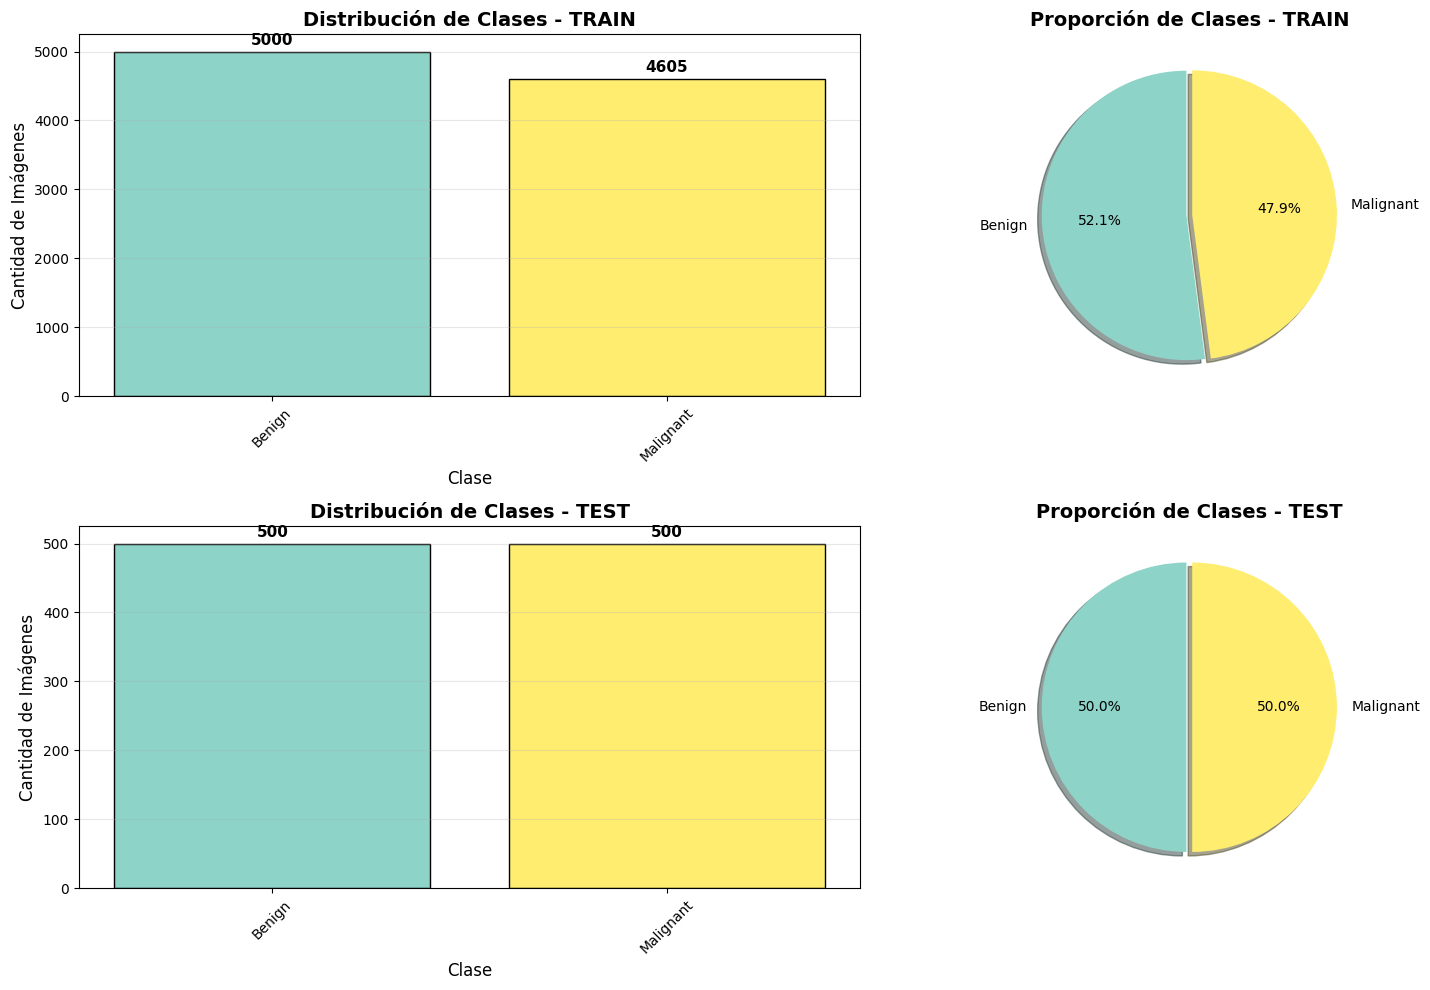

In [46]:
print("="*80)
print("ANÁLISIS EXPLORATORIO DEL DATASET DE MELANOMA")
print("="*80 + "\n")

# Distribución de clases en TRAIN
print("--- Distribución de Clases en TRAIN ---")
unique_train, counts_train = np.unique(y_train, return_counts=True)
df_dist_train = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_train],
    'Cantidad': counts_train,
    'Porcentaje': (counts_train / len(y_train) * 100).round(2)
})
print(df_dist_train.to_string(index=False))

# Distribución de clases en TEST
print("\n--- Distribución de Clases en TEST ---")
unique_test, counts_test = np.unique(y_test, return_counts=True)
df_dist_test = pd.DataFrame({
    'Clase': [CLASS_NAMES[i] for i in unique_test],
    'Cantidad': counts_test,
    'Porcentaje': (counts_test / len(y_test) * 100).round(2)
})
print(df_dist_test.to_string(index=False))

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = plt.cm.Set3(np.linspace(0, 1, len(unique_train)))

# TRAIN - Gráfico de barras
ax1 = axes[0, 0]
ax1.bar([CLASS_NAMES[i] for i in unique_train], counts_train, color=colors, edgecolor='black')
ax1.set_xlabel('Clase', fontsize=12)
ax1.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax1.set_title('Distribución de Clases - TRAIN', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_train, counts_train)):
    ax1.text(i, v + max(counts_train)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# TRAIN - Gráfico circular
ax2 = axes[0, 1]
ax2.pie(counts_train, labels=[CLASS_NAMES[i] for i in unique_train], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_train), shadow=True, startangle=90)
ax2.set_title('Proporción de Clases - TRAIN', fontsize=14, fontweight='bold')

# TEST - Gráfico de barras
ax3 = axes[1, 0]
ax3.bar([CLASS_NAMES[i] for i in unique_test], counts_test, color=colors, edgecolor='black')
ax3.set_xlabel('Clase', fontsize=12)
ax3.set_ylabel('Cantidad de Imágenes', fontsize=12)
ax3.set_title('Distribución de Clases - TEST', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for i, (v, c) in enumerate(zip(counts_test, counts_test)):
    ax3.text(i, v + max(counts_test)*0.02, str(c), ha='center', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# TEST - Gráfico circular
ax4 = axes[1, 1]
ax4.pie(counts_test, labels=[CLASS_NAMES[i] for i in unique_test], autopct='%1.1f%%',
        colors=colors, explode=[0.02]*len(unique_test), shadow=True, startangle=90)
ax4.set_title('Proporción de Clases - TEST', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)


Visualizando muestras del dataset de TRAIN...



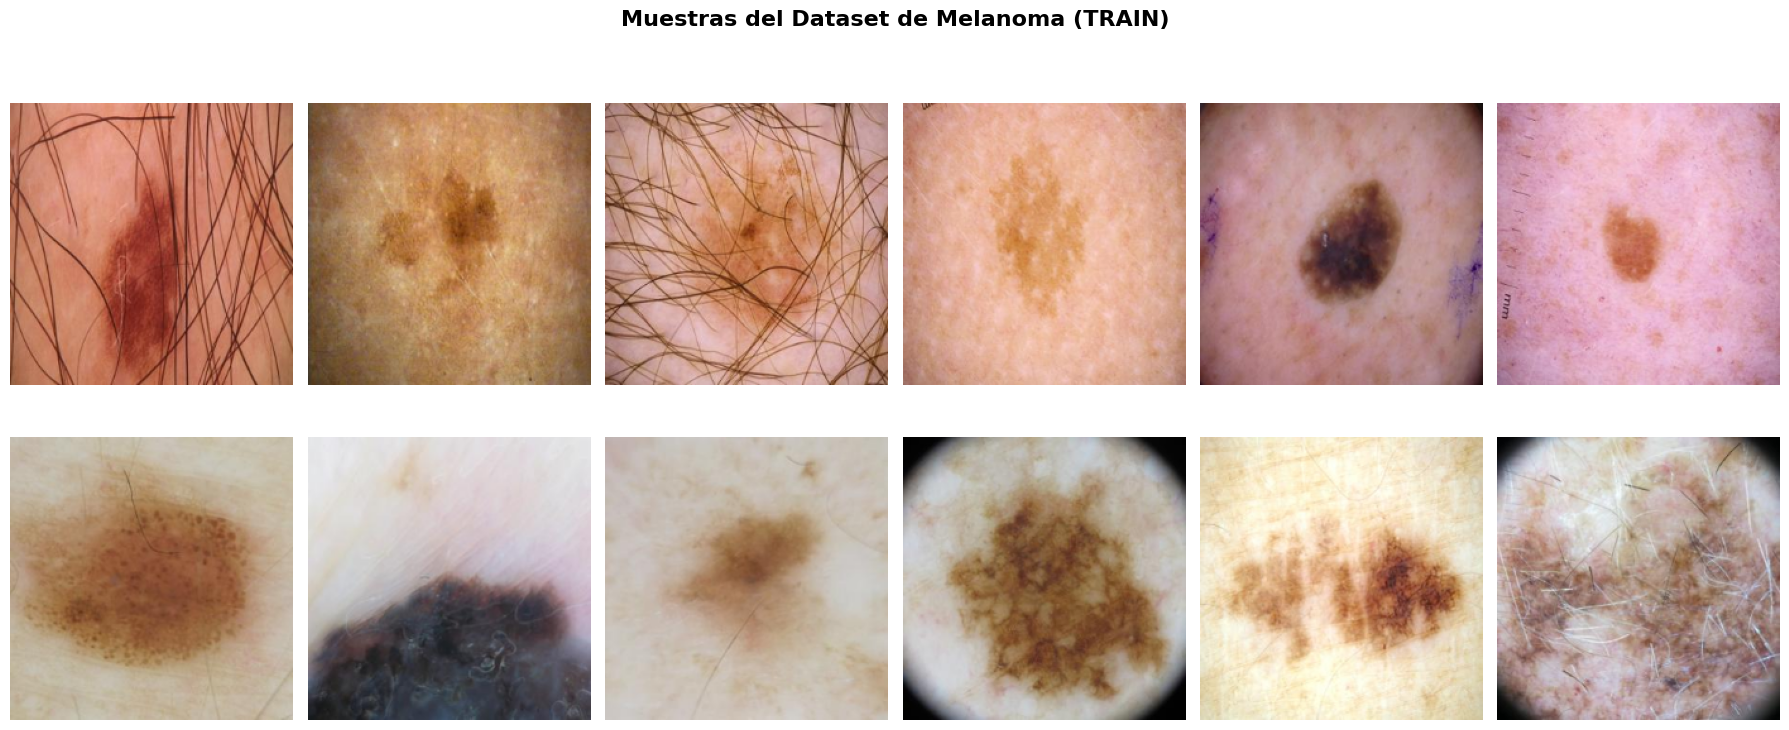

In [47]:
# Visualizar muestras de cada clase (de TRAIN)
print("Visualizando muestras del dataset de TRAIN...\n")

n_classes = len(MAP_CLASSES)
samples_per_class = 6

fig, axes = plt.subplots(n_classes, samples_per_class, figsize=(18, 4*n_classes))

if n_classes == 1:
    axes = [axes]

for idx, label in enumerate(sorted(MAP_CLASSES.keys())):
    indices = np.where(y_train == label)[0]
    np.random.shuffle(indices)
    
    for i in range(min(samples_per_class, len(indices))):
        ax = axes[idx][i] if n_classes > 1 else axes[i]
        ax.imshow(X_train[indices[i]])
        ax.axis('off')
        if i == 0:
            ax.set_ylabel(CLASS_NAMES[label], fontsize=12, rotation=0, 
                         ha='right', va='center')

plt.suptitle('Muestras del Dataset de Melanoma (TRAIN)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Preparación de Datos

In [48]:
print("="*80)
print("PREPARACIÓN DE DATOS")
print("="*80 + "\n")

# Normalizar las imágenes (importante para Transfer Learning)
print("Normalizando imágenes para Transfer Learning...")
# Los modelos pre-entrenados esperan valores en [0, 1] o normalizados según ImageNet
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"Rango normalizado TRAIN: [{X_train_normalized.min():.2f}, {X_train_normalized.max():.2f}]")
print(f"Rango normalizado TEST: [{X_test_normalized.min():.2f}, {X_test_normalized.max():.2f}]")

# Convertir etiquetas a one-hot encoding
print("\nConvirtiendo etiquetas a one-hot encoding...")
y_train_categorical = keras.utils.to_categorical(y_train, len(MAP_CLASSES))
y_test_categorical = keras.utils.to_categorical(y_test, len(MAP_CLASSES))
print(f"Forma de y_train_categorical: {y_train_categorical.shape}")
print(f"Forma de y_test_categorical: {y_test_categorical.shape}")

# Crear conjunto de VALIDATION a partir de TRAIN (20% del train)
print("\nCreando conjunto de VALIDATION a partir de TRAIN (80/20)...")
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_normalized, y_train_categorical,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

# Etiquetas sin one-hot para métricas
y_train_labels = np.argmax(y_train_final, axis=1)
y_val_labels = np.argmax(y_val, axis=1)
y_test_labels = np.argmax(y_test_categorical, axis=1)

print(f"\n📊 Resumen de la división final:")
print(f"   Training: {X_train_final.shape[0]:,} imágenes ({X_train_final.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Validation: {X_val.shape[0]:,} imágenes ({X_val.shape[0]/(len(X_train)+len(X_test))*100:.1f}% del total)")
print(f"   Test: {X_test_normalized.shape[0]:,} imágenes ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}% del total)")

# Verificar distribución
print("\n📊 Distribución de clases por conjunto:")
for name, labels in [("Training", y_train_labels),
                      ("Validation", y_val_labels),
                      ("Test", y_test_labels)]:
    unique_labels, counts_labels = np.unique(labels, return_counts=True)
    dist_str = ", ".join([f"{CLASS_NAMES[l]}={c}" for l, c in zip(unique_labels, counts_labels)])
    print(f"   {name}: {dist_str}")

print("\n" + "="*80)


PREPARACIÓN DE DATOS

Normalizando imágenes para Transfer Learning...
Rango normalizado TRAIN: [0.00, 1.00]
Rango normalizado TEST: [0.00, 1.00]

Convirtiendo etiquetas a one-hot encoding...
Forma de y_train_categorical: (9605, 2)
Forma de y_test_categorical: (1000, 2)

Creando conjunto de VALIDATION a partir de TRAIN (80/20)...

📊 Resumen de la división final:
   Training: 7,684 imágenes (72.5% del total)
   Validation: 1,921 imágenes (18.1% del total)
   Test: 1,000 imágenes (9.4% del total)

📊 Distribución de clases por conjunto:
   Training: Benign=4000, Malignant=3684
   Validation: Benign=1000, Malignant=921
   Test: Benign=500, Malignant=500



## Data Augmentation

In [49]:
print("="*80)
print("CONFIGURACIÓN DE DATA AUGMENTATION")
print("="*80 + "\n")

print("Data Augmentation ayuda a:")
print("  • Aumentar artificialmente el tamaño del dataset")
print("  • Mejorar la generalización del modelo")
print("  • Reducir el overfitting")
print("  • Hacer el modelo más robusto a variaciones\n")

# Generador de datos con augmentation para training
train_datagen = ImageDataGenerator(
    rotation_range=20,           # Rotación aleatoria hasta 20 grados
    width_shift_range=0.2,       # Desplazamiento horizontal
    height_shift_range=0.2,      # Desplazamiento vertical
    horizontal_flip=True,        # Volteo horizontal
    vertical_flip=True,          # Volteo vertical
    zoom_range=0.15,             # Zoom aleatorio
    shear_range=0.15,            # Transformación de corte
    fill_mode='nearest'          # Rellenar píxeles después de transformación
)

# Para validation y test, solo normalización (sin augmentation)
val_test_datagen = ImageDataGenerator()

# Crear generadores
train_generator = train_datagen.flow(
    X_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_generator = val_test_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    seed=SEED
)

print("✅ Generadores de datos configurados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps por época (training): {len(train_generator)}")
print(f"   Steps por época (validation): {len(val_generator)}")

print("\n" + "="*80)


CONFIGURACIÓN DE DATA AUGMENTATION

Data Augmentation ayuda a:
  • Aumentar artificialmente el tamaño del dataset
  • Mejorar la generalización del modelo
  • Reducir el overfitting
  • Hacer el modelo más robusto a variaciones

✅ Generadores de datos configurados
   Batch size: 32
   Steps por época (training): 241
   Steps por época (validation): 61



Ejemplos de Data Augmentation aplicado a una imagen:



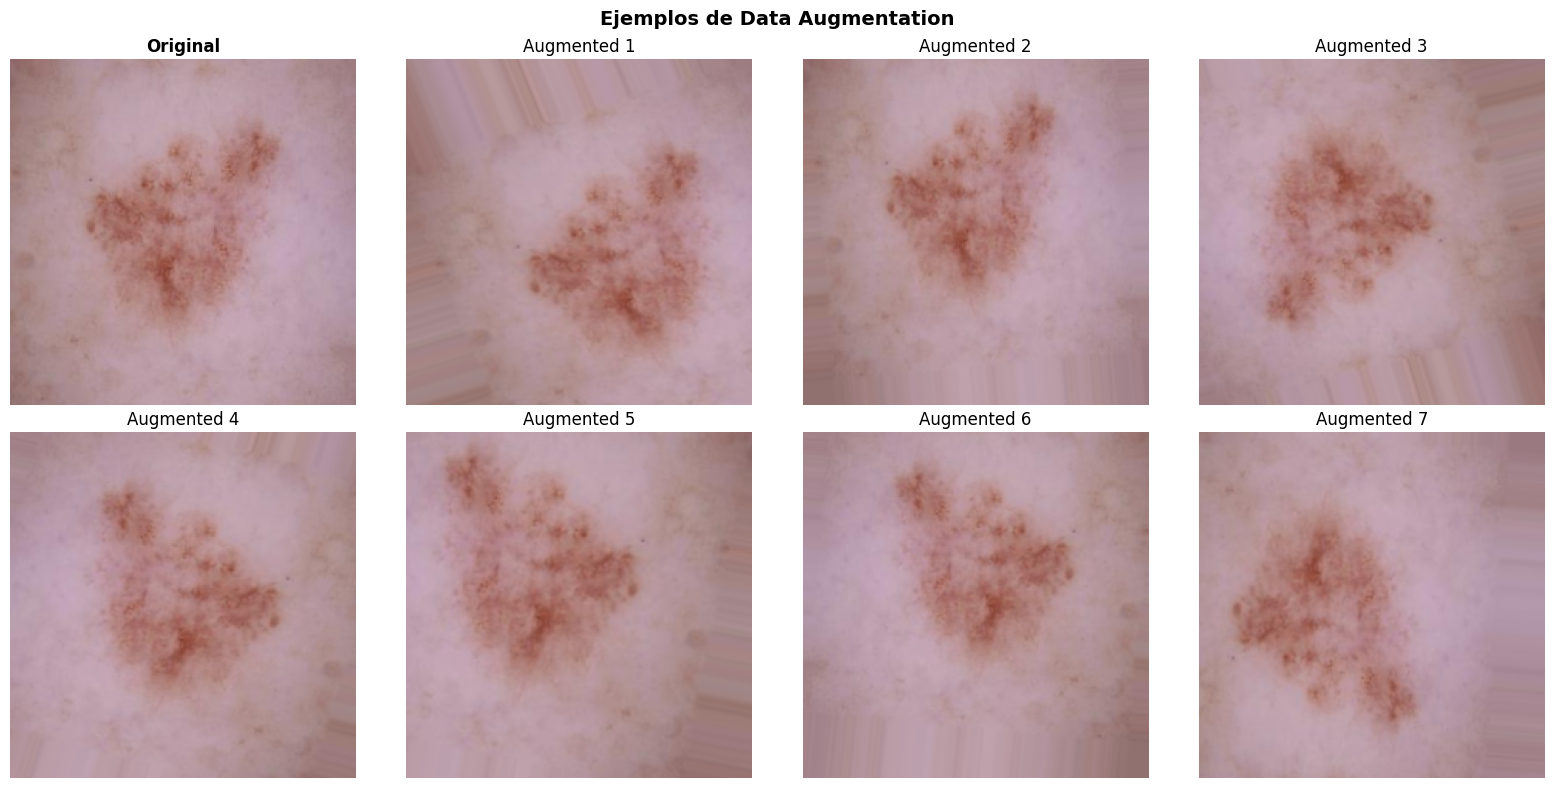

In [50]:
# Visualizar ejemplos de Data Augmentation
print("Ejemplos de Data Augmentation aplicado a una imagen:\n")

# Tomar una imagen de ejemplo
sample_img = X_train_final[0:1]  # Shape (1, 224, 224, 3)
sample_label = y_train_final[0:1]

# Generar versiones augmentadas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Generar 7 versiones augmentadas
aug_gen = train_datagen.flow(sample_img, sample_label, batch_size=1)

for i in range(7):
    row = (i + 1) // 4
    col = (i + 1) % 4
    aug_img = next(aug_gen)[0][0]
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented {i+1}', fontsize=12)
    axes[row, col].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Transfer Learning - Construcción del Modelo

In [51]:
print("="*80)
print("TRANSFER LEARNING - CONSTRUCCIÓN DEL MODELO")
print("="*80 + "\n")

print("Modelos pre-entrenados disponibles:")
print("  1. VGG16 - 138M parámetros (clásico, simple)")
print("  2. ResNet50 - 25.6M parámetros (residual connections)")
print("  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)")
print("  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)\n")

# Elegir modelo base (puedes cambiar esto)
MODEL_NAME = 'MobileNetV2'  # Opciones: 'VGG16', 'ResNet50', 'EfficientNetB0', 'MobileNetV2'

print(f"Modelo seleccionado: {MODEL_NAME}\n")

# Cargar modelo base pre-entrenado (sin la capa superior de clasificación)
if MODEL_NAME == 'VGG16':
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'ResNet50':
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'EfficientNetB0':
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
elif MODEL_NAME == 'MobileNetV2':
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

print(f"✅ Modelo base '{MODEL_NAME}' cargado con pesos de ImageNet")

# Congelar las capas del modelo base (Transfer Learning)
print("\nCongelando capas del modelo base...")
base_model.trainable = False

print(f"✅ Capas congeladas: {len(base_model.layers)}")
print("   Solo entrenaremos las nuevas capas superiores\n")

# Construir el modelo completo
print("Construyendo modelo con capas personalizadas...")

model = models.Sequential([
    # Modelo base pre-entrenado
    base_model,
    
    # Capas de pooling y clasificación personalizadas
    layers.GlobalAveragePooling2D(name='global_avg_pool'),
    
    layers.Dense(512, activation='relu', name='dense1'),
    layers.BatchNormalization(name='bn1'),
    layers.Dropout(0.5, name='dropout1'),
    
    layers.Dense(256, activation='relu', name='dense2'),
    layers.BatchNormalization(name='bn2'),
    layers.Dropout(0.5, name='dropout2'),
    
    # Capa de salida
    layers.Dense(len(MAP_CLASSES), activation='softmax', name='output')
], name=f'TransferLearning_{MODEL_NAME}')

# Compilar el modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Modelo compilado")
print("\n--- Resumen del Modelo ---")
model.summary()

# Información de parámetros
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print(f"\n📊 Parámetros del modelo:")
print(f"   Totales: {trainable_params + non_trainable_params:,}")
print(f"   Entrenables: {trainable_params:,}")
print(f"   No entrenables (congelados): {non_trainable_params:,}")
print(f"   Porcentaje entrenable: {trainable_params/(trainable_params + non_trainable_params)*100:.2f}%")

print("\n" + "="*80)

TRANSFER LEARNING - CONSTRUCCIÓN DEL MODELO

Modelos pre-entrenados disponibles:
  1. VGG16 - 138M parámetros (clásico, simple)
  2. ResNet50 - 25.6M parámetros (residual connections)
  3. EfficientNetB0 - 5.3M parámetros (eficiente, moderno)
  4. MobileNetV2 - 3.5M parámetros (ligero, rápido)

Modelo seleccionado: MobileNetV2

✅ Modelo base 'MobileNetV2' cargado con pesos de ImageNet

Congelando capas del modelo base...
✅ Capas congeladas: 154
   Solo entrenaremos las nuevas capas superiores

Construyendo modelo con capas personalizadas...

✅ Modelo compilado

--- Resumen del Modelo ---
Model: "TransferLearning_MobileNetV2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_avg_pool (GlobalAver  (None, 

## Entrenamiento del Modelo con Transfer Learning

In [52]:
print("="*80)
print("ENTRENAMIENTO DEL MODELO CON TRANSFER LEARNING")
print("="*80 + "\n")

# Configurar callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurados:")
print("  • EarlyStopping: patience=10, restore_best_weights=True")
print("  • ReduceLROnPlateau: factor=0.5, patience=5\n")

print("Iniciando entrenamiento...\n")
print(f"Épocas máximas: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Usando GPU: {len(tf.config.list_physical_devices('GPU')) > 0}\n")
print("="*80 + "\n")

# Entrenar el modelo
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*80)
print("ENTRENAMIENTO COMPLETADO")
print("="*80)


ENTRENAMIENTO DEL MODELO CON TRANSFER LEARNING

Callbacks configurados:
  • EarlyStopping: patience=10, restore_best_weights=True
  • ReduceLROnPlateau: factor=0.5, patience=5

Iniciando entrenamiento...

Épocas máximas: 50
Batch size: 32
Usando GPU: True


Epoch 1/50
241/241 [==============================] - 57s 226ms/step - loss: 0.4631 - accuracy: 0.8255 - val_loss: 0.2920 - val_accuracy: 0.8824 - lr: 0.0010
Epoch 2/50
241/241 [==============================] - 48s 201ms/step - loss: 0.3485 - accuracy: 0.8563 - val_loss: 0.2759 - val_accuracy: 0.8766 - lr: 0.0010
Epoch 3/50
241/241 [==============================] - 50s 205ms/step - loss: 0.3089 - accuracy: 0.8713 - val_loss: 0.2705 - val_accuracy: 0.8787 - lr: 0.0010
Epoch 4/50
241/241 [==============================] - 49s 204ms/step - loss: 0.3024 - accuracy: 0.8751 - val_loss: 0.2636 - val_accuracy: 0.8860 - lr: 0.0010
Epoch 5/50
241/241 [==============================] - 48s 200ms/step - loss: 0.2855 - accuracy: 0.8798 - val_l

## Análisis de Curvas de Aprendizaje

ANÁLISIS DE CURVAS DE APRENDIZAJE



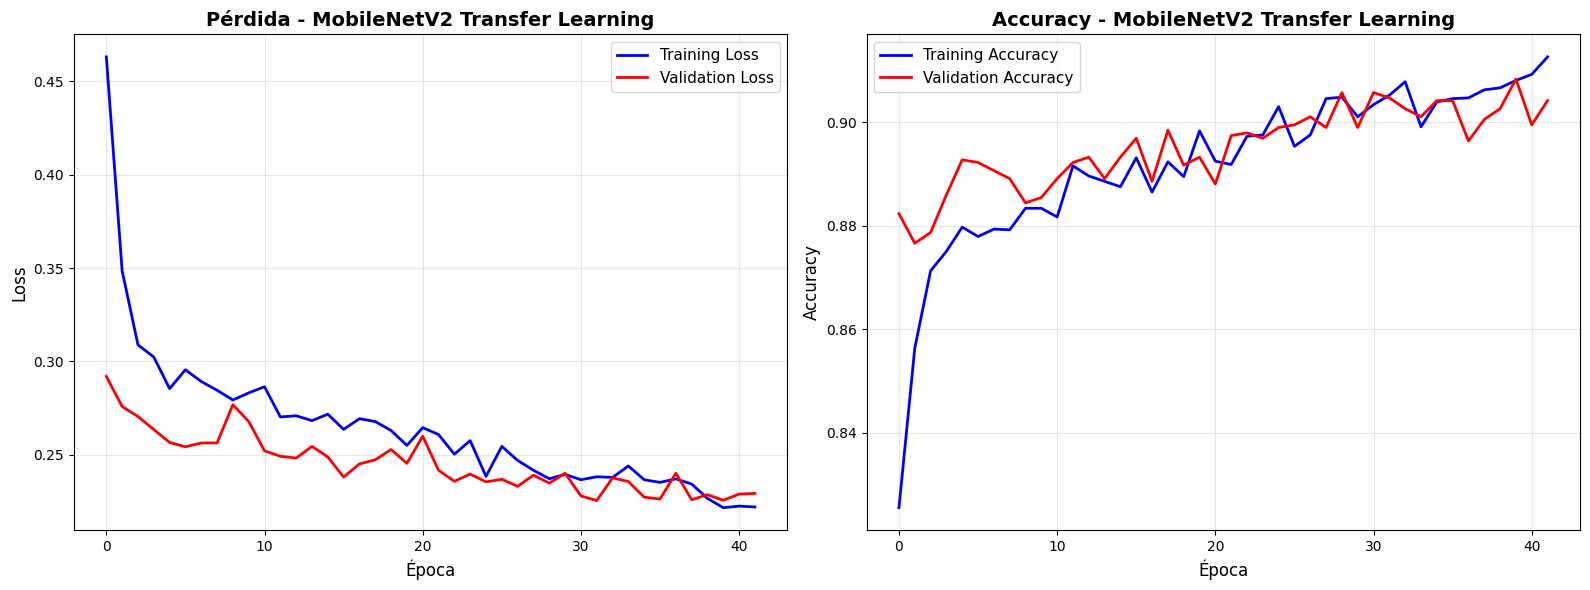

Épocas entrenadas: 42
Mejor época: 32
Mejor val_loss: 0.2255
Mejor val_accuracy: 0.9047 (90.47%)

Accuracy final Training: 0.9127
Accuracy final Validation: 0.9042
Diferencia: 0.0085
✅ Modelo bien generalizado



In [53]:
print("="*80)
print("ANÁLISIS DE CURVAS DE APRENDIZAJE")
print("="*80 + "\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pérdida
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
ax1.set_title(f'Pérdida - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gráfico de accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
ax2.set_title(f'Accuracy - {MODEL_NAME} Transfer Learning', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas del entrenamiento
epochs_trained = len(history.history['loss'])
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
best_val_acc = history.history['val_accuracy'][best_epoch]

print(f"Épocas entrenadas: {epochs_trained}")
print(f"Mejor época: {best_epoch + 1}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# Análisis de overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
diff_acc = final_train_acc - final_val_acc

print(f"\nAccuracy final Training: {final_train_acc:.4f}")
print(f"Accuracy final Validation: {final_val_acc:.4f}")
print(f"Diferencia: {diff_acc:.4f}")

if diff_acc > 0.1:
    print("⚠️ Posible overfitting detectado (diferencia > 10%)")
elif diff_acc > 0.05:
    print("⚠️ Ligero overfitting (diferencia > 5%)")
else:
    print("✅ Modelo bien generalizado")

print("\n" + "="*80)

## Evaluación en Conjunto de Test

In [54]:
print("="*80)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("="*80 + "\n")

# Evaluar el modelo
test_loss, test_accuracy = model.evaluate(X_test_normalized, y_test_categorical, verbose=0)

print(f"📊 Resultados en Test:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Realizar predicciones
print("\nRealizando predicciones...")
y_pred_proba = model.predict(X_test_normalized, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calcular métricas
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(y_test_labels, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test_labels, y_pred, average='macro', zero_division=0
)

print(f"\n📊 Métricas Globales:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Precision (macro): {precision:.4f}")
print(f"   Recall (macro): {recall:.4f}")
print(f"   F1-Score (macro): {f1:.4f}")

print("\n" + "="*80)


EVALUACIÓN EN CONJUNTO DE TEST

📊 Resultados en Test:
   Loss: 0.2213
   Accuracy: 0.9060 (90.60%)

Realizando predicciones...

📊 Métricas Globales:
   Accuracy: 0.9060
   Precision (macro): 0.9086
   Recall (macro): 0.9060
   F1-Score (macro): 0.9058



## Métricas Detalladas por Clase

In [55]:
print("="*80)
print("MÉTRICAS DETALLADAS POR CLASE")
print("="*80 + "\n")

# Reporte de clasificación
class_names_list = [CLASS_NAMES[i] for i in sorted(MAP_CLASSES.keys())]
print("--- Reporte de Clasificación ---")
print(classification_report(y_test_labels, y_pred, 
                          target_names=class_names_list, 
                          zero_division=0))

# Métricas por clase en DataFrame
precision_per_class, recall_per_class, f1_per_class, support_per_class = \
    precision_recall_fscore_support(y_test_labels, y_pred, average=None, zero_division=0)

df_metricas = pd.DataFrame({
    'Clase': class_names_list,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Muestras': support_per_class
})

print("\n--- Tabla de Métricas ---")
print(df_metricas.to_string(index=False))

print("\n" + "="*80)

MÉTRICAS DETALLADAS POR CLASE

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Benign       0.88      0.95      0.91       500
   Malignant       0.94      0.87      0.90       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000


--- Tabla de Métricas ---
    Clase  Precision  Recall  F1-Score  Muestras
   Benign   0.875926   0.946  0.909615       500
Malignant   0.941304   0.866  0.902083       500



## Matriz de Confusión

MATRIZ DE CONFUSIÓN



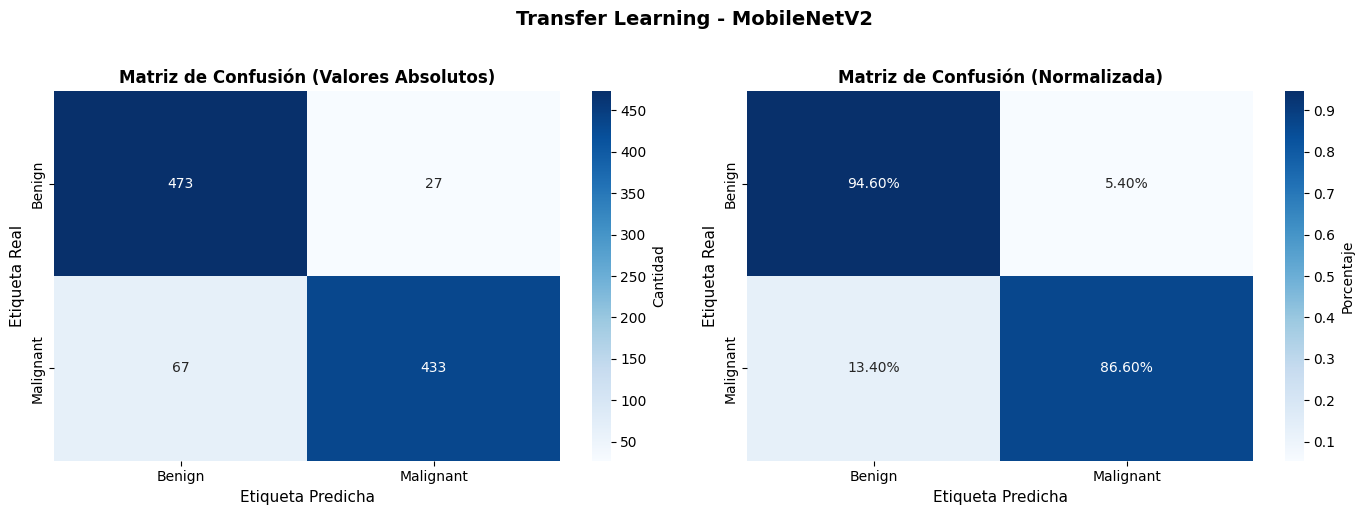

In [56]:
print("="*80)
print("MATRIZ DE CONFUSIÓN")
print("="*80 + "\n")

# Calcular matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Valores absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list,
            yticklabels=class_names_list,
            cbar_kws={'label': 'Cantidad'},
            ax=ax1)
ax1.set_title('Matriz de Confusión (Valores Absolutos)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Etiqueta Real', fontsize=11)
ax1.set_xlabel('Etiqueta Predicha', fontsize=11)

# Normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names_list,
            yticklabels=class_names_list,
            cbar_kws={'label': 'Porcentaje'},
            ax=ax2)
ax2.set_title('Matriz de Confusión (Normalizada)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Etiqueta Real', fontsize=11)
ax2.set_xlabel('Etiqueta Predicha', fontsize=11)

plt.suptitle(f'Transfer Learning - {MODEL_NAME}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*80)

## Visualización de Predicciones

VISUALIZACIÓN DE PREDICCIONES



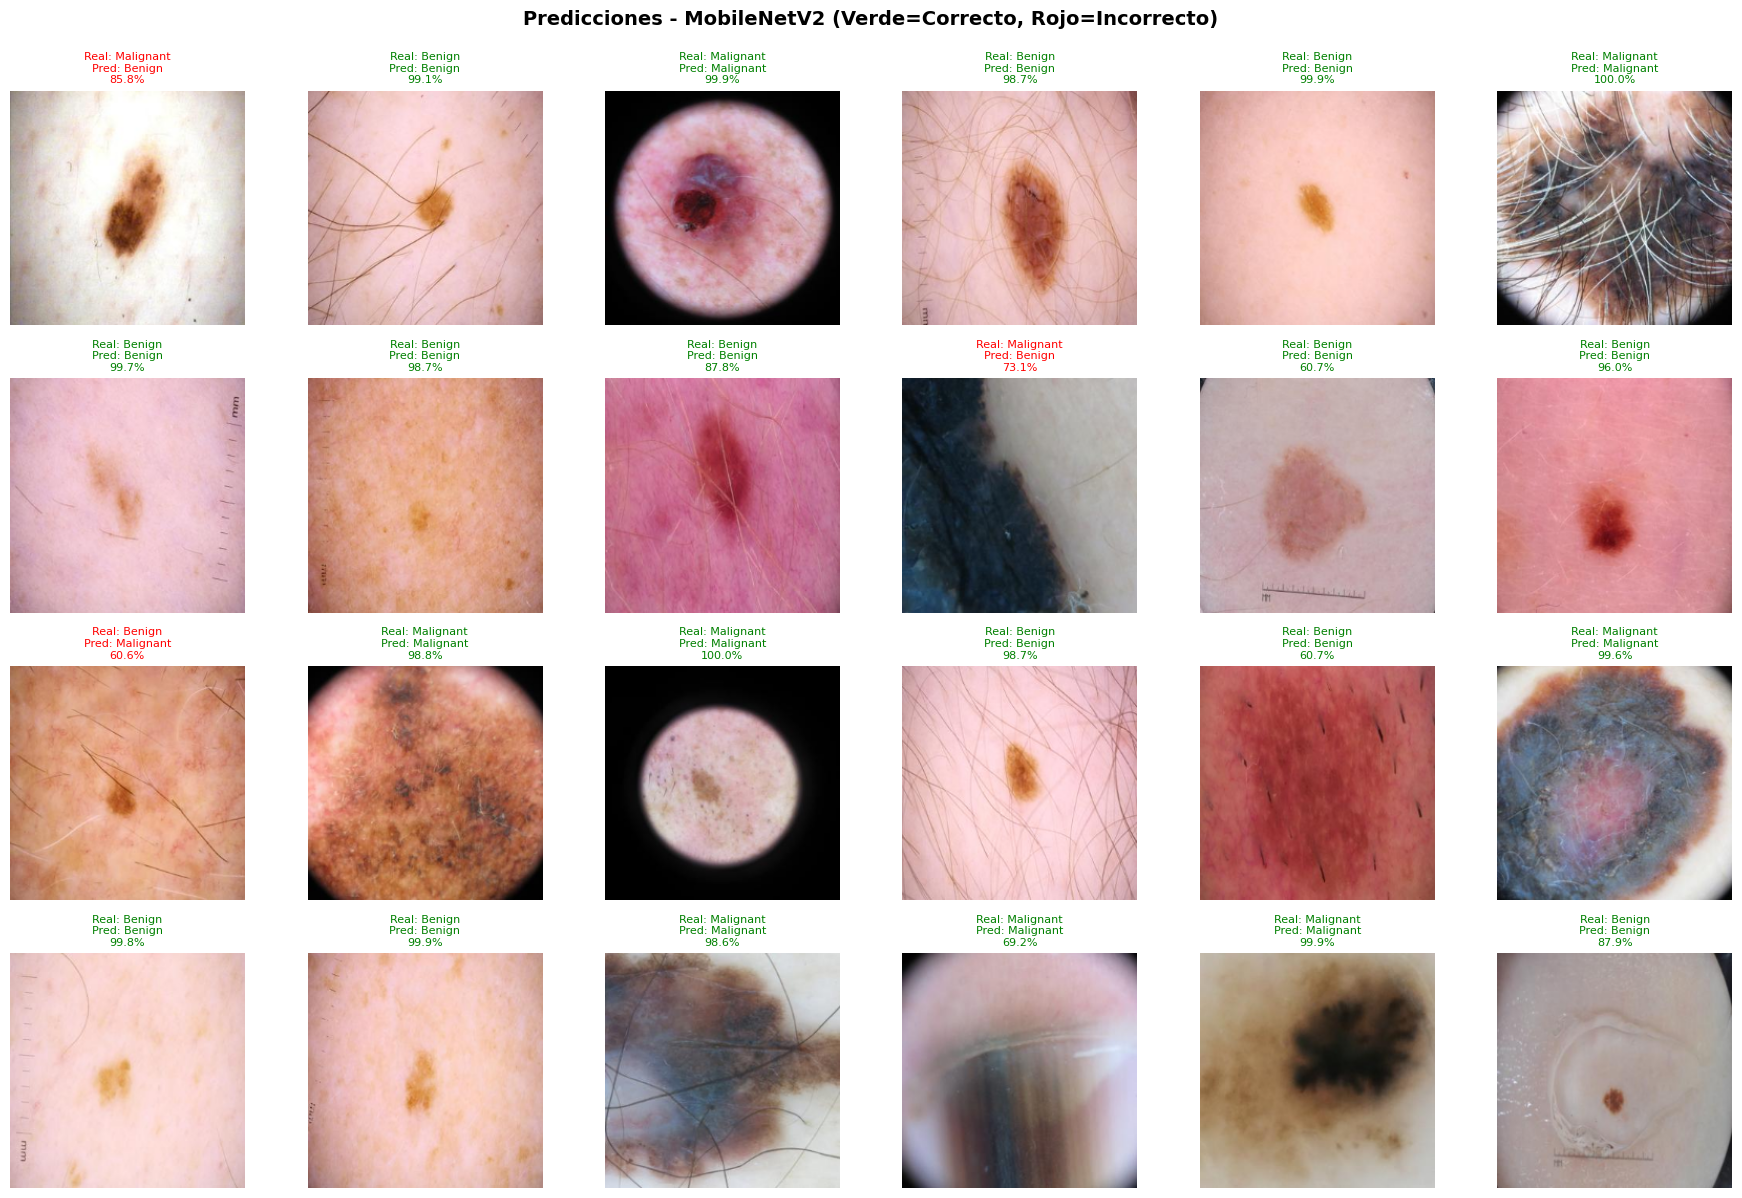

Predicciones correctas: 906/1000 (90.60%)
Predicciones incorrectas: 94/1000 (9.40%)



In [57]:
print("="*80)
print("VISUALIZACIÓN DE PREDICCIONES")
print("="*80 + "\n")

# Desnormalizar para visualización
X_test_display = (X_test_normalized * 255).astype(np.uint8)

# Seleccionar muestras aleatorias
np.random.seed(42)
num_samples = min(24, len(X_test_normalized))
random_indices = np.random.choice(len(X_test_normalized), num_samples, replace=False)

# Visualizar
plt.figure(figsize=(18, 12))
for i, idx in enumerate(random_indices):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_test_display[idx])

    true_label = CLASS_NAMES[y_test_labels[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_proba[idx][y_pred[idx]] * 100

    is_correct = y_test_labels[idx] == y_pred[idx]
    color = 'green' if is_correct else 'red'

    title = f'Real: {true_label}\nPred: {pred_label}\n{confidence:.1f}%'
    plt.title(title, fontsize=8, color=color)
    plt.axis('off')

plt.suptitle(f'Predicciones - {MODEL_NAME} (Verde=Correcto, Rojo=Incorrecto)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Estadísticas
correctas = np.sum(y_pred == y_test_labels)
incorrectas = len(y_test_labels) - correctas

print(f"Predicciones correctas: {correctas}/{len(y_test_labels)} ({correctas/len(y_test_labels)*100:.2f}%)")
print(f"Predicciones incorrectas: {incorrectas}/{len(y_test_labels)} ({incorrectas/len(y_test_labels)*100:.2f}%)")

print("\n" + "="*80)


## Resumen Final

In [62]:
print("="*80)
print(f"RESUMEN FINAL - TRANSFER LEARNING CON {MODEL_NAME}")
print("="*80 + "\n")

print("📊 INFORMACIÓN DEL MODELO")
print("-" * 80)
print(f"Modelo base: {MODEL_NAME} (pre-entrenado en ImageNet)")
print(f"Técnica: Transfer Learning")
print(f"Tamaño de entrada: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Número de clases: {len(MAP_CLASSES)}")
print(f"Data Augmentation: Activado")

print(f"\n🎯 RESULTADOS EN TEST")
print("-" * 80)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-Score (macro): {f1:.4f}")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS - CLASIFICACIÓN DE MELANOMA")
print("="*80)

RESUMEN FINAL - TRANSFER LEARNING CON MobileNetV2

📊 INFORMACIÓN DEL MODELO
--------------------------------------------------------------------------------
Modelo base: MobileNetV2 (pre-entrenado en ImageNet)
Técnica: Transfer Learning
Tamaño de entrada: 224x224x3
Número de clases: 2
Data Augmentation: Activado

🎯 RESULTADOS EN TEST
--------------------------------------------------------------------------------
Accuracy: 0.9060 (90.60%)
Precision (macro): 0.9086
Recall (macro): 0.9060
F1-Score (macro): 0.9058

FIN DEL ANÁLISIS - CLASIFICACIÓN DE MELANOMA
